# Credit Risk Scoring — EDA & Modeling

**Dataset:** [Give Me Some Credit](https://www.kaggle.com/c/GiveMeSomeCredit) (Kaggle), ~150,000 anonymized consumer credit records.

**Business problem:** Given an applicant's credit profile, estimate the probability they will experience serious delinquency (90+ days past due) within the next two years, then translate that probability into a scaled credit score and risk tier a lending team can act on directly.

**Target:** `SeriousDlqin2yrs` (1 = defaulted, 0 = did not)


In [1]:
import sys
sys.path.insert(0, "..")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_prep import load_raw, clean_and_engineer, RAW_FEATURES, TARGET

pd.set_option("display.max_columns", 50)
sns.set_style("whitegrid")

raw = load_raw("../data/raw/cs-training.csv")
raw.shape

(150000, 11)

## 1. First look at the raw data

In [2]:
raw.head()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [3]:
raw[TARGET].value_counts(normalize=True).rename("share").to_frame()

,share
SeriousDlqin2yrs,
0,0.93316
1,0.06684


Base rate is ~6.7% -- a meaningfully imbalanced target, which shapes the modeling choices later (class weighting, and evaluating with AUC/KS/PR-AUC rather than raw accuracy).

In [4]:
missing = raw.isna().mean().sort_values(ascending=False)
missing[missing > 0].rename("pct_missing").to_frame()

,pct_missing
MonthlyIncome,0.198207
NumberOfDependents,0.026160


`MonthlyIncome` is missing for ~20% of records and `NumberOfDependents` for ~2.6%. Both are imputed in `clean_and_engineer`, with a `_missing` flag kept as its own feature since "didn't report income" can itself be predictive.

In [5]:
raw[RAW_FEATURES].describe().T

,count,mean,std,min,25%,50%,75%,max
RevolvingUtilizationOfUnsecuredLines,150000.0,6.048438,249.755371,0.0,0.029867,0.154181,0.559046,50708.0
age,150000.0,52.295207,14.771866,0.0,41.000000,52.000000,63.000000,109.0
NumberOfTime30-59DaysPastDueNotWorse,150000.0,0.421033,4.192781,0.0,0.000000,0.000000,0.000000,98.0
DebtRatio,150000.0,353.005076,2037.818523,0.0,0.175074,0.366508,0.868254,329664.0
MonthlyIncome,120269.0,6670.221237,14384.674215,0.0,3400.000000,5400.000000,8249.000000,3008750.0
NumberOfOpenCreditLinesAndLoans,150000.0,8.452760,5.145951,0.0,5.000000,8.000000,11.000000,58.0
NumberOfTimes90DaysLate,150000.0,0.265973,4.169304,0.0,0.000000,0.000000,0.000000,98.0
NumberRealEstateLoansOrLines,150000.0,1.018240,1.129771,0.0,0.000000,1.000000,2.000000,54.0
NumberOfTime60-89DaysPastDueNotWorse,150000.0,0.240387,4.155179,0.0,0.000000,0.000000,0.000000,98.0
NumberOfDependents,146076.0,0.757222,1.115086,0.0,0.000000,0.000000,1.000000,20.0


A few columns have implausible maxima: `RevolvingUtilizationOfUnsecuredLines` and `DebtRatio` both have values in the thousands (should realistically sit under ~2), and the "times past due" columns have a cluster of records at 96/98, which are data-entry sentinel codes rather than real counts. These are capped/handled in `src/data_prep.py` rather than dropped, to avoid throwing away otherwise-valid records.

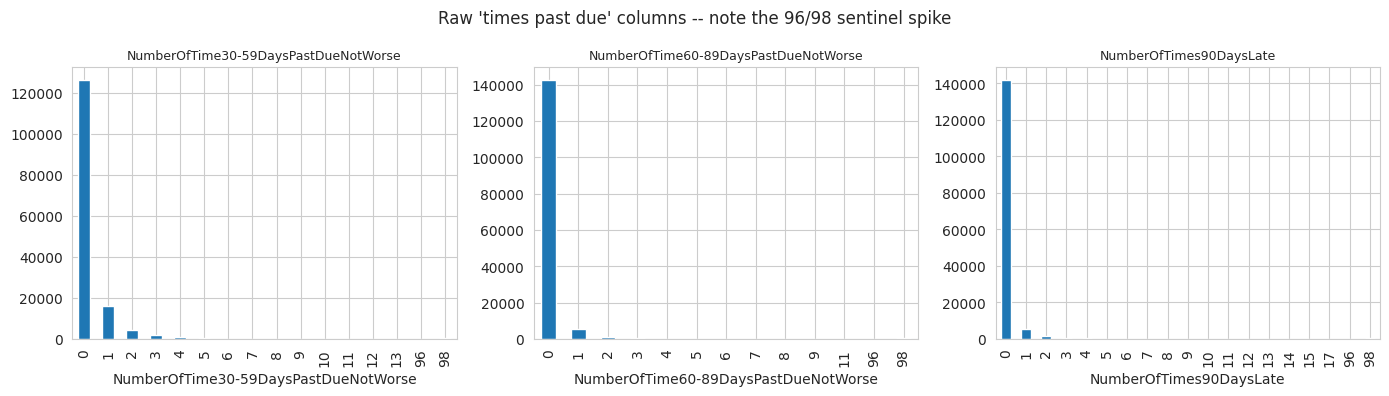

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, ["NumberOfTime30-59DaysPastDueNotWorse", "NumberOfTime60-89DaysPastDueNotWorse", "NumberOfTimes90DaysLate"]):
    raw[col].value_counts().sort_index().plot(kind="bar", ax=ax)
    ax.set_title(col, fontsize=9)
fig.suptitle("Raw 'times past due' columns -- note the 96/98 sentinel spike")
fig.tight_layout()
plt.show()

## 2. Cleaning & feature engineering

In [7]:
clean = clean_and_engineer(raw)
clean.shape

(150000, 21)

In [8]:
clean[["RevolvingUtilization_capped", "DebtRatio", "TotalTimesPastDue", "HasPastDueHistory", "IncomePerDependent"]].describe().T

,count,mean,std,min,25%,50%,75%,max
RevolvingUtilization_capped,150000.0,0.322328,0.356769,0.0,0.029867,0.154181,0.559046,1.366269e+00
DebtRatio,150000.0,325.217939,955.301614,0.0,0.175074,0.366508,0.868254,6.186010e+03
TotalTimesPastDue,150000.0,0.429047,1.283798,0.0,0.000000,0.000000,0.000000,1.900000e+01
HasPastDueHistory,150000.0,0.202420,0.401805,0.0,0.000000,0.000000,0.000000,1.000000e+00
IncomePerDependent,150000.0,4589.119181,7974.493101,0.0,2151.000000,4000.000000,5400.000000,1.794060e+06


## 3. What separates defaulters from non-defaulters?

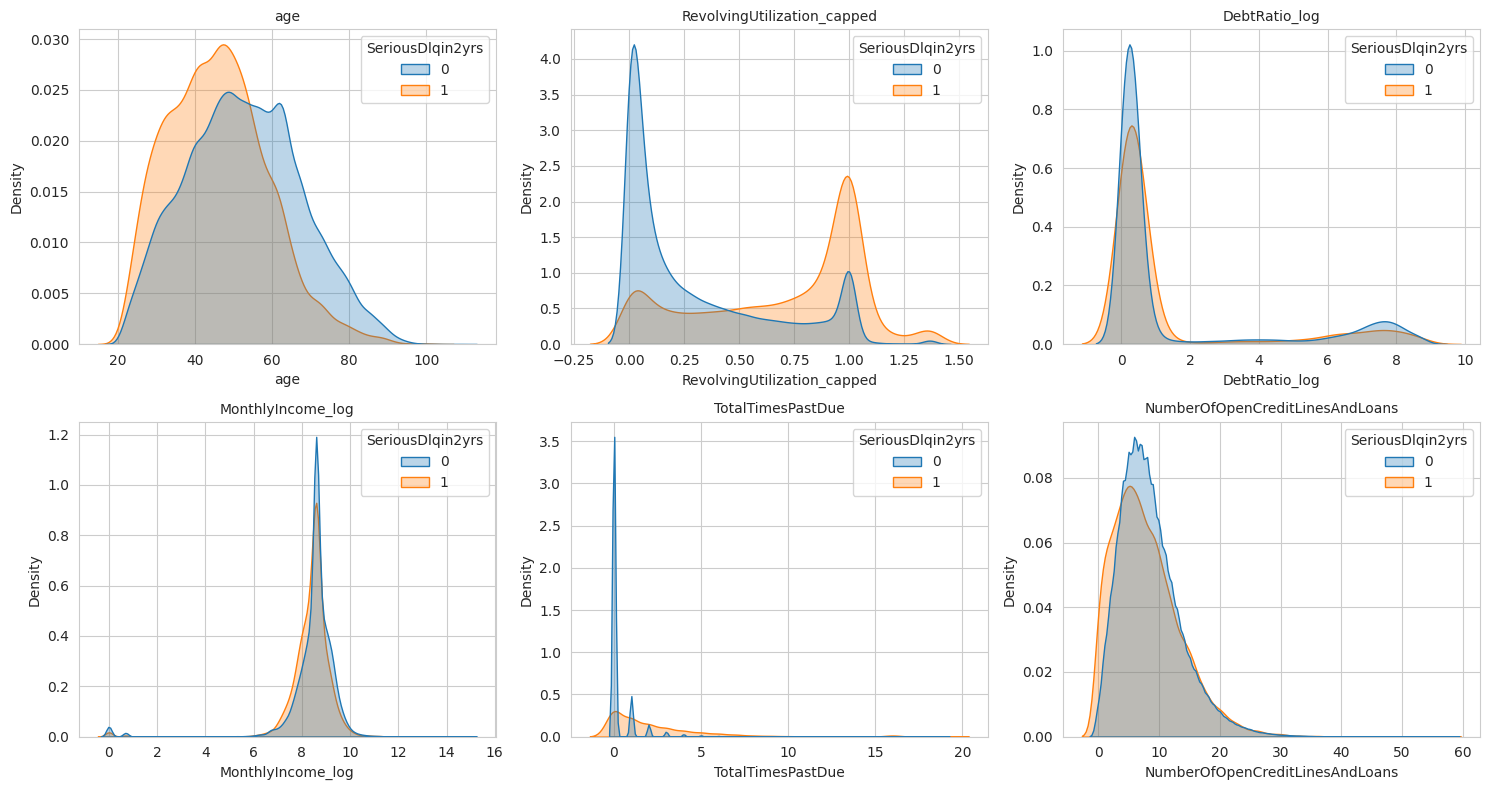

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
feats = ["age", "RevolvingUtilization_capped", "DebtRatio_log", "MonthlyIncome_log",
         "TotalTimesPastDue", "NumberOfOpenCreditLinesAndLoans"]
for ax, feat in zip(axes.ravel(), feats):
    sns.kdeplot(data=clean, x=feat, hue=TARGET, common_norm=False, ax=ax, fill=True, alpha=0.3)
    ax.set_title(feat, fontsize=10)
fig.tight_layout()
plt.show()

Clear separation on delinquency history and utilization (as expected -- these are the strongest classic risk signals), a milder but real signal on age (younger borrowers default more) and income.

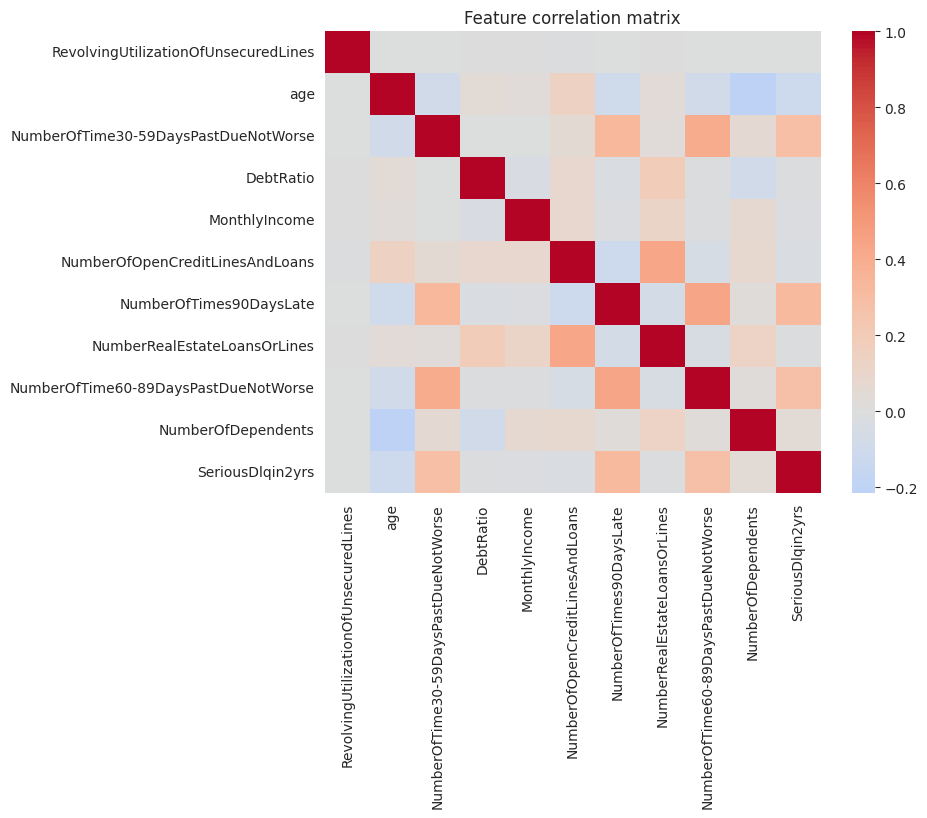

In [10]:
corr = clean[RAW_FEATURES + [TARGET]].corr()
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False, ax=ax)
ax.set_title("Feature correlation matrix")
plt.show()

No pair of raw features is worryingly collinear, so no features were dropped purely for correlation reasons -- the past-due columns are the exception, which is why they're combined into `TotalTimesPastDue` for a cleaner single signal in addition to being kept individually.

## 4. Modeling, evaluation, and scoring

Full training pipeline lives in `src/train.py` (logistic regression baseline + XGBoost, evaluated on a held-out 25% test split with ROC-AUC, PR-AUC, KS-statistic, and Gini -- the standard credit-risk scorecard metrics). Results are re-loaded here from `models/metrics.json` produced by that script; run `python -m src.train` from the project root to regenerate.

In [11]:
import json
with open("../models/metrics.json") as f:
    metrics = json.load(f)
pd.DataFrame(metrics).T

,roc_auc,pr_auc,ks_statistic,gini,confusion_matrix_at_0.5,top_decile_capture_rate
logistic_regression,0.8628,0.3885,0.5712,0.7255,"{'true_negative': 28256, 'false_positive': 673...",NaN
xgboost,0.8684,0.4032,0.5757,0.7368,"{'true_negative': 28215, 'false_positive': 677...",0.5547


XGBoost edges out the logistic-regression baseline on every metric, but not by a huge margin -- consistent with how these models usually compare in practice: the regression stays a strong, fully auditable baseline (regulators/compliance can read its coefficients directly), and the gradient-boosted model earns its complexity with a real but modest lift, plus materially better ranking at the top of the risk distribution (KS, top-decile capture).

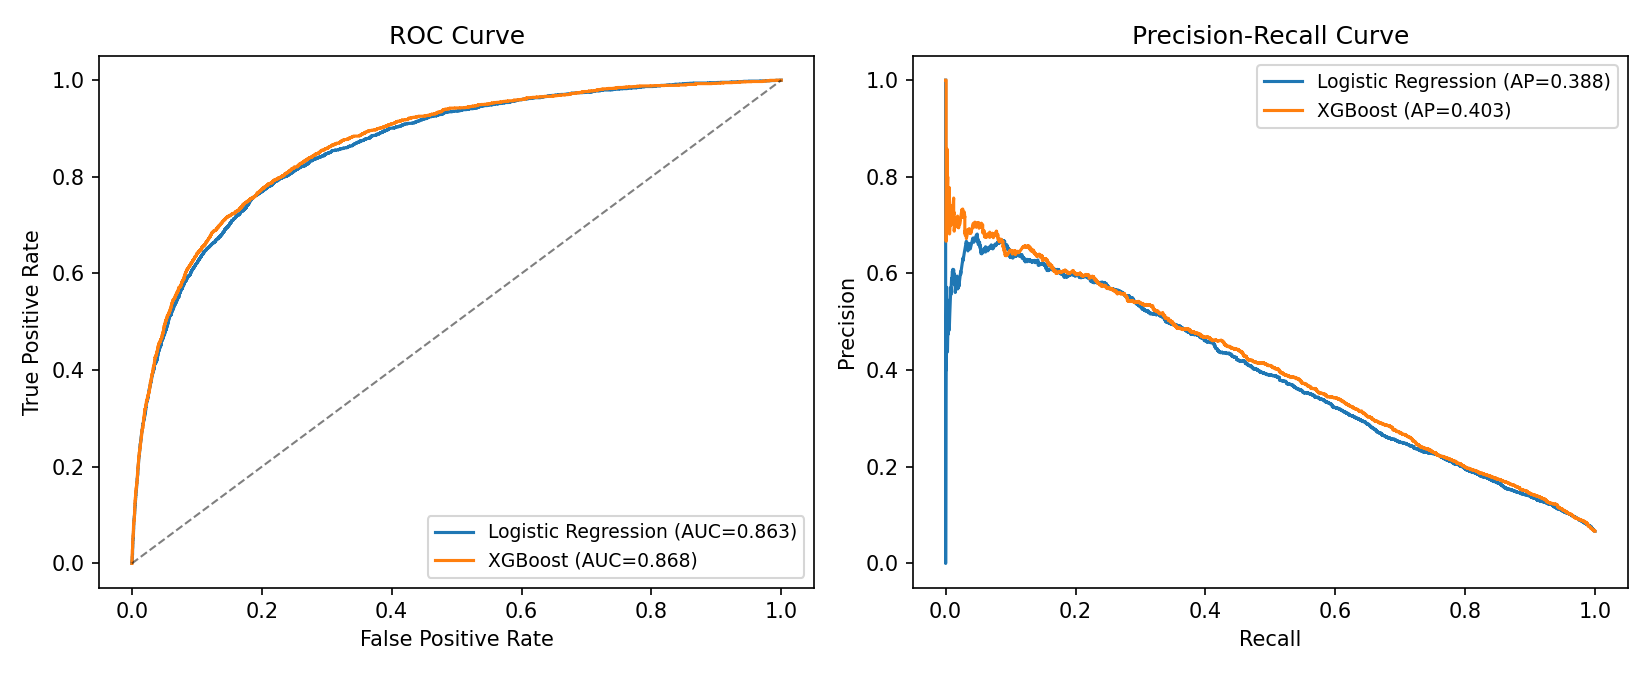

In [12]:
from IPython.display import Image
Image("../reports/figures/roc_pr_curves.png")

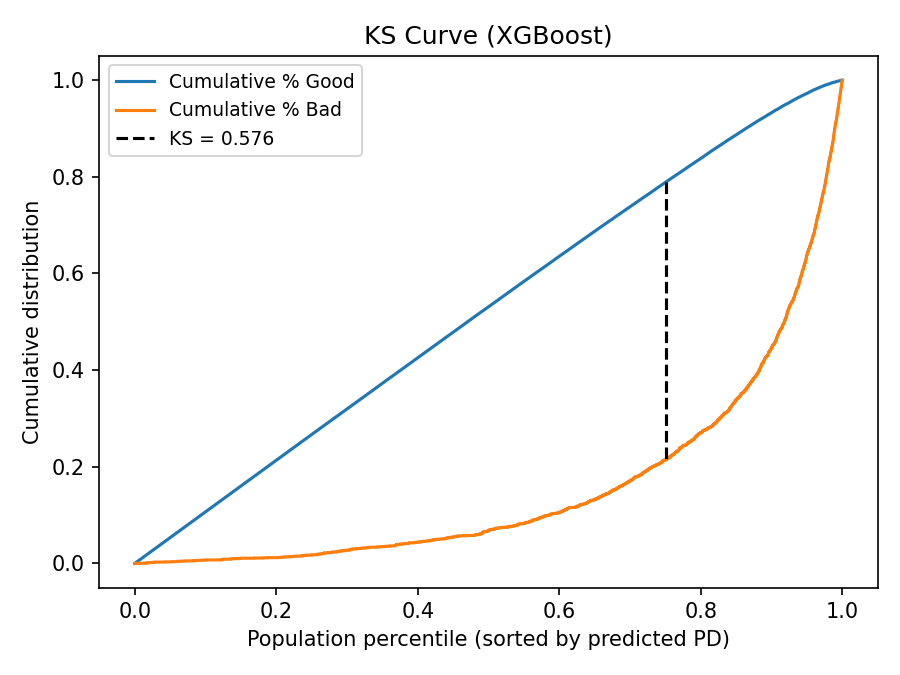

In [13]:
Image("../reports/figures/ks_curve.png")

**KS ≈ 0.58** -- the maximum separation between the cumulative "good" and "bad" distributions across the score range. In credit risk, KS > 0.4 is considered good discrimination and > 0.5 is very good; this model is comfortably in that range.

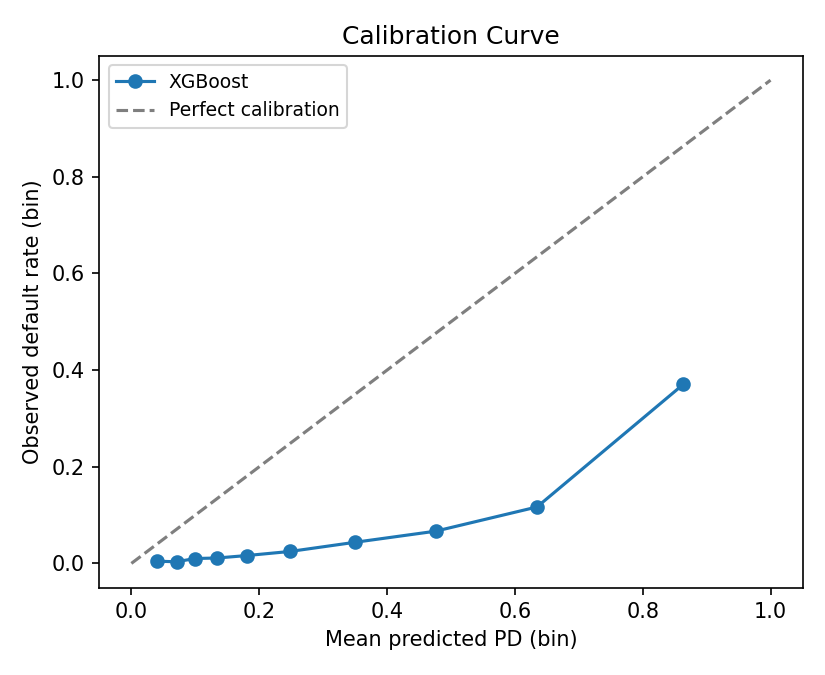

In [14]:
Image("../reports/figures/calibration.png")

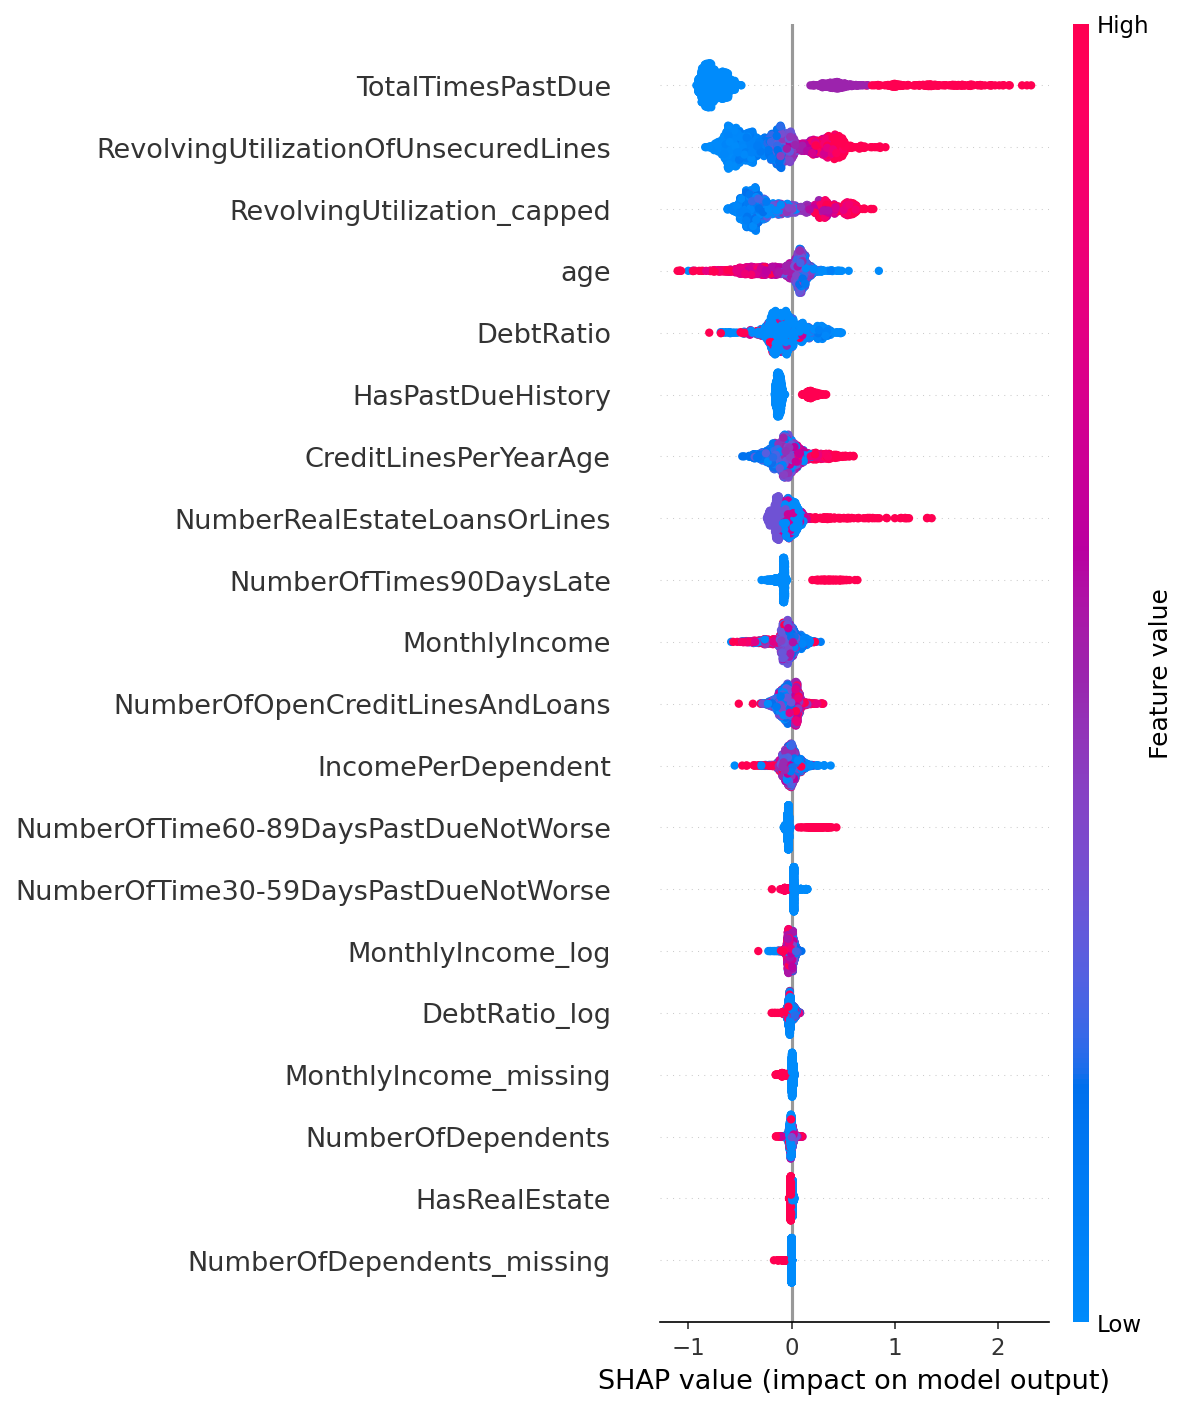

In [15]:
Image("../reports/figures/shap_summary.png")

SHAP confirms the EDA: prior delinquency count and revolving utilization dominate the prediction, followed by age and debt ratio -- all consistent with standard credit-risk intuition, which is a useful sanity check that the model hasn't latched onto something spurious.

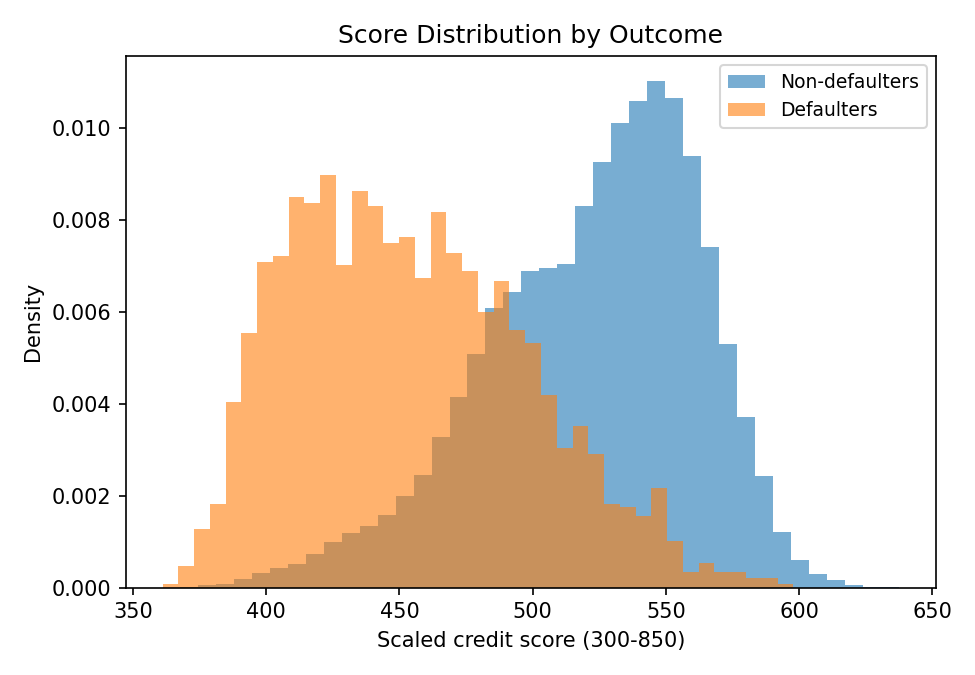

In [16]:
Image("../reports/figures/score_distribution.png")

## 5. From probability to score

Raw probabilities are translated into a 300-850 scaled score using the same points-to-double-the-odds transform that underlies commercial credit scorecards (`src/scorecard.py`). Non-defaulters and defaulters separate cleanly across the score range above, which is the practical test of whether the score is usable for cutoff-based decisioning (e.g. auto-approve above X, manual review Y-X, decline below Y).

## 6. Business takeaway

In [17]:
from IPython.display import Markdown
capture = metrics["xgboost"]["top_decile_capture_rate"]
Markdown(
    f"Targeting the riskiest **10%** of applicants by predicted score catches "
    f"**{capture:.0%}** of actual defaults in the test set -- i.e. a lending team using "
    f"this model to flag applications for manual underwriting review would only need to "
    f"review one in ten applications to catch over half of the bad debt before it happens."
)

Targeting the riskiest **10%** of applicants by predicted score catches **55%** of actual defaults in the test set -- i.e. a lending team using this model to flag applications for manual underwriting review would only need to review one in ten applications to catch over half of the bad debt before it happens.